In [ ]:
import os
import numpy as np
import pandas as pd
import tensorflow as tf
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from tensorflow.keras import layers, models

print(tf.__version__)

2.21.0


In [ ]:
# Set up file paths for the dataset
BASE_DIR = "archive/chest_xray/chest_xray"

TRAIN_DIR = os.path.join(BASE_DIR, "train")
VAL_DIR = os.path.join(BASE_DIR, "val")
TEST_DIR  = os.path.join(BASE_DIR, "test")

for split, path in [("Train", TRAIN_DIR), ("Val", VAL_DIR), ("Test", TEST_DIR)]:
    for label in ["NORMAL", "PNEUMONIA"]:
        count = len(os.listdir(os.path.join(path, label)))
        print(f"{split} | {label}: {count} images")

Train | NORMAL: 1342 images
Train | PNEUMONIA: 3876 images
Val | NORMAL: 9 images
Val | PNEUMONIA: 9 images
Test | NORMAL: 234 images
Test | PNEUMONIA: 390 images


In [ ]:
#Load image file paths from training and validation directories
train_filenames = tf.io.gfile.glob(os.path.join(TRAIN_DIR, "*", "*"))
val_filenames = tf.io.gfile.glob(os.path.join(VAL_DIR, "*", "*"))

filenames = train_filenames + val_filenames
filenames = [f for f in filenames if f.lower().endswith(('.jpg', '.jpeg', '.png'))]

train_filenames, val_filenames = train_test_split(filenames, test_size = 0.2, random_state = 42)

COUNT_NORMAL = len([f for f in train_filenames if "NORMAL" in f])
COUNT_PNEUMONIA = len([f for f in train_filenames if "PNEUMONIA" in f])
print("Normal images count in training set:", COUNT_NORMAL)
print("Pneumonia images count in training set:", COUNT_PNEUMONIA)

train_list_ds = tf.data.Dataset.from_tensor_slices(train_filenames)
val_list_ds = tf.data.Dataset.from_tensor_slices(val_filenames)

TRAIN_IMG_COUNT = tf.data.experimental.cardinality(train_list_ds).numpy()
VAL_IMG_COUNT = tf.data.experimental.cardinality(val_list_ds).numpy()
print("Training images count:", TRAIN_IMG_COUNT)
print("Validating images count:", VAL_IMG_COUNT)

CLASS_NAMES = np.array([os.path.basename(p) for p in tf.io.gfile.glob(os.path.join(TRAIN_DIR, "*")) 
                        if not os.path.basename(p).startswith('.')])
print(CLASS_NAMES)


Normal images count in training set: 1059
Pneumonia images count in training set: 3126
Training images count: 4185
Validating images count: 1047
['NORMAL' 'PNEUMONIA']


In [ ]:
# Create a DataFrame to summarize the dataset
df = pd.DataFrame({
    'filename': filenames,
    'label': ['PNEUMONIA' if 'PNEUMONIA' in f else 'NORMAL' for f in filenames]
})

print("First 5 rows:")
display(df.head())

print("Last 5 rows:")
display(df.tail())

First 5 rows:


,filename,label
0,archive\chest_xray\chest_xray\train\NORMAL\IM-...,NORMAL
1,archive\chest_xray\chest_xray\train\NORMAL\IM-...,NORMAL
2,archive\chest_xray\chest_xray\train\NORMAL\IM-...,NORMAL
3,archive\chest_xray\chest_xray\train\NORMAL\IM-...,NORMAL
4,archive\chest_xray\chest_xray\train\NORMAL\IM-...,NORMAL


Last 5 rows:


,filename,label
5227,archive\chest_xray\chest_xray\val\PNEUMONIA\pe...,PNEUMONIA
5228,archive\chest_xray\chest_xray\val\PNEUMONIA\pe...,PNEUMONIA
5229,archive\chest_xray\chest_xray\val\PNEUMONIA\pe...,PNEUMONIA
5230,archive\chest_xray\chest_xray\val\PNEUMONIA\pe...,PNEUMONIA
5231,archive\chest_xray\chest_xray\val\PNEUMONIA\pe...,PNEUMONIA


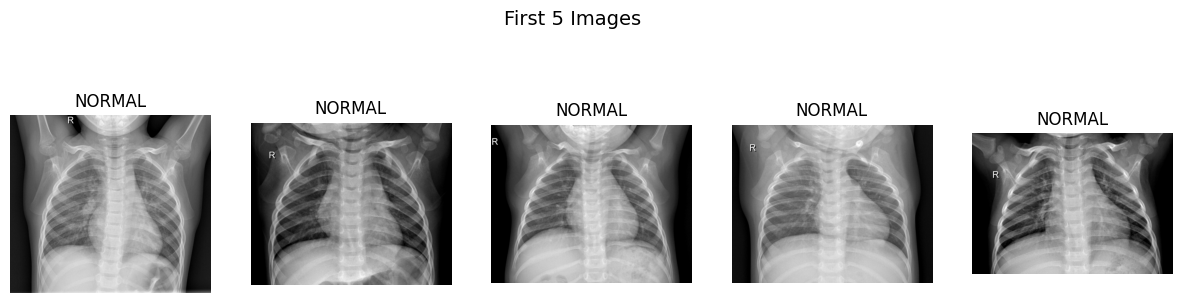

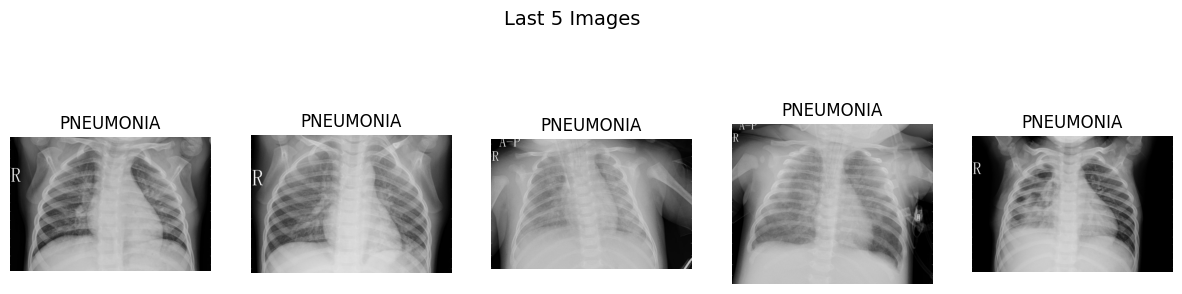

In [ ]:
 #Visualize some sample images from the dataset
def show_images(file_list, title):
    plt.figure(figsize=(15, 4))
    plt.suptitle(title, fontsize=14)
    for i, filepath in enumerate(file_list):
        img = tf.io.read_file(filepath)
        img = tf.image.decode_jpeg(img, channels=3)
        ax = plt.subplot(1, 5, i + 1)
        plt.imshow(img)
        label = "PNEUMONIA" if "PNEUMONIA" in filepath else "NORMAL"
        plt.title(label)
        plt.axis("off")
    plt.show()

show_images(filenames[:5], "First 5 Images")
show_images(filenames[-5:], "Last 5 Images")

In [ ]:
# Set up parameters for data processing and model training
AUTOTUNE = tf.data.experimental.AUTOTUNE
IMAGE_SIZE = [180, 180]   # matches source
BATCH_SIZE = 16           # matches source

def get_label(file_path):
    parts = tf.strings.split(file_path, os.path.sep)
    return parts[-2] == "PNEUMONIA"

def decode_img(img):
    img = tf.image.decode_jpeg(img, channels=3)
    img = tf.image.convert_image_dtype(img, tf.float32)
    return tf.image.resize(img, IMAGE_SIZE)

def process_path(file_path):
    label = get_label(file_path)
    label = tf.cast(label, tf.float32)
    img = tf.io.read_file(file_path)
    img = decode_img(img)
    return img, label

train_ds = train_list_ds.map(process_path, num_parallel_calls=AUTOTUNE)
val_ds   = val_list_ds.map(process_path, num_parallel_calls=AUTOTUNE)

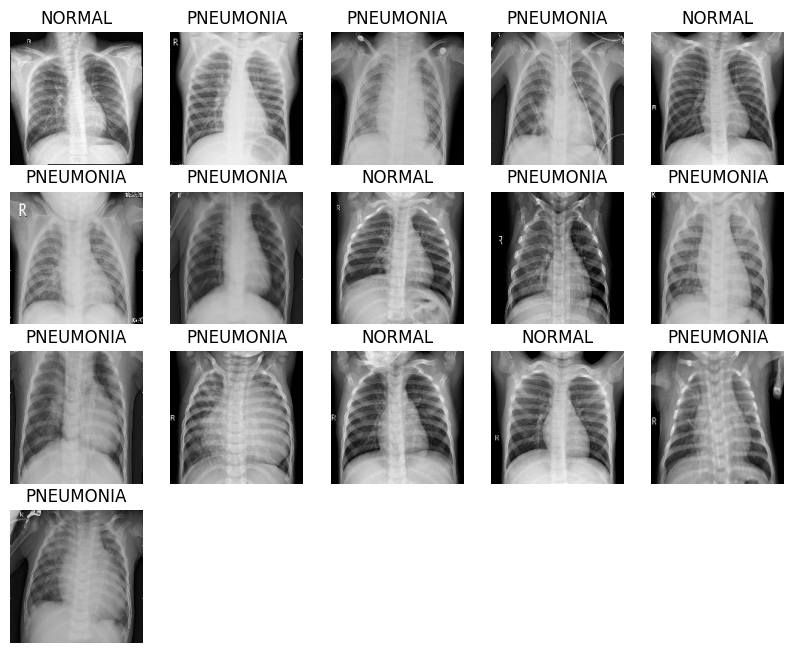

In [ ]:
# Prepare the datasets for training by caching, shuffling, batching, and prefetching
def prepare_for_training(ds, cache=True, shuffle_buffer_size=1000):
    if cache:
        ds = ds.cache() if cache is True else ds.cache(cache)
    ds = ds.repeat()
    ds = ds.shuffle(buffer_size=shuffle_buffer_size)
    ds = ds.batch(BATCH_SIZE)
    ds = ds.prefetch(buffer_size=AUTOTUNE)
    return ds

train_ds = prepare_for_training(train_ds)
val_ds   = prepare_for_training(val_ds)

image_batch, label_batch = next(iter(train_ds))
image_batch = image_batch.numpy()
label_batch = label_batch.numpy()

def show_batch(image_batch, label_batch):
    plt.figure(figsize = (10,10))
    n_show = min(25, image_batch.shape[0])
    for n in range(n_show):
        ax = plt.subplot(5,5,n+1)
        plt.imshow(image_batch[n])
        plt.title("PNEUMONIA" if label_batch[n] > 0.5 else "NORMAL")
        plt.axis("off")

show_batch(image_batch, label_batch)


In [ ]:
# Build the convolutional neural network model architecture using convolutional and dense blocks
def conv_block(filters):
    block = tf.keras.Sequential([
        tf.keras.layers.SeparableConv2D(filters, 3, activation='relu', padding='same'),
        tf.keras.layers.SeparableConv2D(filters, 3, activation='relu', padding='same'),
        tf.keras.layers.BatchNormalization(),
        tf.keras.layers.MaxPool2D()
    ])
    return block

def dense_block(units, dropout_rate):
    block = tf.keras.Sequential([
        tf.keras.layers.Dense(units, activation='relu'),
        tf.keras.layers.BatchNormalization(),
        tf.keras.layers.Dropout(dropout_rate)
    ])
    return block

def build_model():
    model = tf.keras.Sequential([
        tf.keras.Input(shape=(IMAGE_SIZE[0], IMAGE_SIZE[1], 3)),

        tf.keras.layers.Conv2D(16, 3, activation='relu', padding='same'),
        tf.keras.layers.Conv2D(16, 3, activation='relu', padding='same'),
        tf.keras.layers.MaxPool2D(),

        conv_block(32),
        conv_block(64),

        conv_block(128),
        tf.keras.layers.Dropout(0.2),

        conv_block(256),
        tf.keras.layers.Dropout(0.2),

        tf.keras.layers.Flatten(),
        dense_block(512, 0.7),
        dense_block(128, 0.5),
        dense_block(64, 0.3),

        tf.keras.layers.Dense(1, activation='sigmoid')
    ])
    return model

In [ ]:
# Calculate class weights to address class imbalance in the dataset
initial_bias = np.log([COUNT_PNEUMONIA / COUNT_NORMAL])
weight_for_0 = (1 / COUNT_NORMAL) * (TRAIN_IMG_COUNT) / 2.0
weight_for_1 = (1 / COUNT_PNEUMONIA) * (TRAIN_IMG_COUNT) / 2.0

class_weight = {0: weight_for_0, 1: weight_for_1}
print("Weight for class 0:", weight_for_0)
print("Weight for class 1:", weight_for_1)

model = build_model()

METRICS = [
    'accuracy',
    tf.keras.metrics.Precision(name='precision'),
    tf.keras.metrics.Recall(name='recall')
]

model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=METRICS
)

Weight for class 0: 1.9759206798866857
Weight for class 1: 0.6693857965451055


In [ ]:
# Set up callbacks for model checkpointing and early stopping during training
checkpoint_cb = tf.keras.callbacks.ModelCheckpoint("xray_model.keras",
                                                    save_best_only=True)

early_stopping_cb = tf.keras.callbacks.EarlyStopping(patience=10,
                                                     restore_best_weights=True)

In [ ]:
# Train the model with class weights and callbacks
def exponential_decay(lr0, s):
    def exponential_decay_fn(epoch):
        return lr0 * 0.1 **(epoch / s)
    return exponential_decay_fn

exponential_decay_fn = exponential_decay(0.01, 20)

lr_scheduler = tf.keras.callbacks.LearningRateScheduler(exponential_decay_fn)

In [ ]:
# Train the model with class weights and callbacks
EPOCHS = 25

history = model.fit(
    train_ds,
    steps_per_epoch=TRAIN_IMG_COUNT // BATCH_SIZE,
    epochs=EPOCHS,
    validation_data=val_ds,
    validation_steps=VAL_IMG_COUNT // BATCH_SIZE,
    class_weight=class_weight,
    callbacks=[checkpoint_cb, early_stopping_cb, lr_scheduler]
)

Epoch 1/25
261/261 ━━━━━━━━━━━━━━━━━━━━ 0s 377ms/step - accuracy: 0.6572 - loss: 0.6454 - precision: 0.8639 - recall: 0.6413

261/261 ━━━━━━━━━━━━━━━━━━━━ 126s 425ms/step - accuracy: 0.7409 - loss: 0.5293 - precision: 0.9043 - recall: 0.7303 - val_accuracy: 0.4875 - val_loss: 1.5888 - val_precision: 0.9440 - val_recall: 0.2963 - learning_rate: 0.0100
Epoch 2/25
261/261 ━━━━━━━━━━━━━━━━━━━━ 84s 321ms/step - accuracy: 0.8453 - loss: 0.3644 - precision: 0.9451 - recall: 0.8412 - val_accuracy: 0.7510 - val_loss: 2.3056 - val_precision: 0.7628 - val_recall: 0.9522 - learning_rate: 0.0089
Epoch 3/25
261/261 ━━━━━━━━━━━━━━━━━━━━ 0s 303ms/step - accuracy: 0.8639 - loss: 0.3286 - precision: 0.9605 - recall: 0.8558

261/261 ━━━━━━━━━━━━━━━━━━━━ 84s 321ms/step - accuracy: 0.8721 - loss: 0.3236 - precision: 0.9563 - recall: 0.8686 - val_accuracy: 0.8577 - val_loss: 0.4805 - val_precision: 0.8780 - val_recall: 0.9319 - learning_rate: 0.0079
Epoch 4/25
261/261 ━━━━━━━━━━━━━━━━━━━━ 0s 307ms/step - accuracy: 0.8862 - loss: 0.2733 - precision: 0.9696 - recall: 0.8773

261/261 ━━━━━━━━━━━━━━━━━━━━ 85s 324ms/step - accuracy: 0.8906 - loss: 0.2703 - precision: 0.9665 - recall: 0.8846 - val_accuracy: 0.9250 - val_loss: 0.1916 - val_precision: 0.9817 - val_recall: 0.9146 - learning_rate: 0.0071
Epoch 5/25
261/261 ━━━━━━━━━━━━━━━━━━━━ 84s 322ms/step - accuracy: 0.9167 - loss: 0.2021 - precision: 0.9785 - recall: 0.9078 - val_accuracy: 0.9269 - val_loss: 0.1995 - val_precision: 0.9246 - val_recall: 0.9803 - learning_rate: 0.0063
Epoch 6/25
261/261 ━━━━━━━━━━━━━━━━━━━━ 83s 317ms/step - accuracy: 0.9200 - loss: 0.2101 - precision: 0.9765 - recall: 0.9152 - val_accuracy: 0.8260 - val_loss: 0.6211 - val_precision: 0.8093 - val_recall: 0.9934 - learning_rate: 0.0056
Epoch 7/25
261/261 ━━━━━━━━━━━━━━━━━━━━ 0s 299ms/step - accuracy: 0.9198 - loss: 0.1951 - precision: 0.9834 - recall: 0.9093

261/261 ━━━━━━━━━━━━━━━━━━━━ 85s 325ms/step - accuracy: 0.9246 - loss: 0.1920 - precision: 0.9805 - recall: 0.9175 - val_accuracy: 0.9442 - val_loss: 0.1443 - val_precision: 0.9426 - val_recall: 0.9827 - learning_rate: 0.0050
Epoch 8/25
261/261 ━━━━━━━━━━━━━━━━━━━━ 0s 298ms/step - accuracy: 0.9344 - loss: 0.1937 - precision: 0.9808 - recall: 0.9303

...

261/261 ━━━━━━━━━━━━━━━━━━━━ 85s 324ms/step - accuracy: 0.9303 - loss: 0.1614 - precision: 0.9846 - recall: 0.9215 - val_accuracy: 0.9692 - val_loss: 0.0837 - val_precision: 0.9765 - val_recall: 0.9817 - learning_rate: 0.0028
Epoch 13/25
261/261 ━━━━━━━━━━━━━━━━━━━━ 83s 318ms/step - accuracy: 0.9327 - loss: 0.1678 - precision: 0.9830 - recall: 0.9260 - val_accuracy: 0.9452 - val_loss: 0.1181 - val_precision: 0.9889 - val_recall: 0.9359 - learning_rate: 0.0025
Epoch 14/25
261/261 ━━━━━━━━━━━━━━━━━━━━ 82s 314ms/step - accuracy: 0.9377 - loss: 0.1625 - precision: 0.9844 - recall: 0.9313 - val_accuracy: 0.9644 - val_loss: 0.0846 - val_precision: 0.9863 - val_recall: 0.9638 - learning_rate: 0.0022
Epoch 15/25
261/261 ━━━━━━━━━━━━━━━━━━━━ 83s 317ms/step - accuracy: 0.9526 - loss: 0.1297 - precision: 0.9870 - recall: 0.9489 - val_accuracy: 0.9615 - val_loss: 0.0942 - val_precision: 0.9945 - val_recall: 0.9522 - learning_rate: 0.0020
Epoch 16/25
261/261 ━━━━━━━━━━━━━━━━━━━━ 0s 305ms/step - acc

261/261 ━━━━━━━━━━━━━━━━━━━━ 84s 323ms/step - accuracy: 0.9579 - loss: 0.1092 - precision: 0.9894 - recall: 0.9540 - val_accuracy: 0.9712 - val_loss: 0.0744 - val_precision: 0.9842 - val_recall: 0.9765 - learning_rate: 0.0018
Epoch 17/25
261/261 ━━━━━━━━━━━━━━━━━━━━ 0s 300ms/step - accuracy: 0.9533 - loss: 0.1123 - precision: 0.9873 - recall: 0.9496

261/261 ━━━━━━━━━━━━━━━━━━━━ 83s 317ms/step - accuracy: 0.9488 - loss: 0.1248 - precision: 0.9875 - recall: 0.9431 - val_accuracy: 0.9683 - val_loss: 0.0737 - val_precision: 0.9877 - val_recall: 0.9679 - learning_rate: 0.0016
Epoch 18/25
261/261 ━━━━━━━━━━━━━━━━━━━━ 82s 316ms/step - accuracy: 0.9579 - loss: 0.1076 - precision: 0.9894 - recall: 0.9539 - val_accuracy: 0.9702 - val_loss: 0.0746 - val_precision: 0.9788 - val_recall: 0.9801 - learning_rate: 0.0014
Epoch 19/25
261/261 ━━━━━━━━━━━━━━━━━━━━ 82s 314ms/step - accuracy: 0.9643 - loss: 0.0925 - precision: 0.9907 - recall: 0.9612 - val_accuracy: 0.9587 - val_loss: 0.0929 - val_precision: 0.9888 - val_recall: 0.9526 - learning_rate: 0.0013
Epoch 20/25
261/261 ━━━━━━━━━━━━━━━━━━━━ 82s 315ms/step - accuracy: 0.9648 - loss: 0.0921 - precision: 0.9927 - recall: 0.9599 - val_accuracy: 0.9625 - val_loss: 0.0774 - val_precision: 0.9917 - val_recall: 0.9561 - learning_rate: 0.0011
Epoch 21/25
261/261 ━━━━━━━━━━━━━━━━━━━━ 84s 323ms/step - ac

261/261 ━━━━━━━━━━━━━━━━━━━━ 83s 317ms/step - accuracy: 0.9763 - loss: 0.0604 - precision: 0.9954 - recall: 0.9729 - val_accuracy: 0.9740 - val_loss: 0.0704 - val_precision: 0.9839 - val_recall: 0.9799 - learning_rate: 7.9433e-04
Epoch 24/25
261/261 ━━━━━━━━━━━━━━━━━━━━ 0s 303ms/step - accuracy: 0.9791 - loss: 0.0624 - precision: 0.9955 - recall: 0.9763

261/261 ━━━━━━━━━━━━━━━━━━━━ 84s 321ms/step - accuracy: 0.9775 - loss: 0.0601 - precision: 0.9947 - recall: 0.9749 - val_accuracy: 0.9683 - val_loss: 0.0679 - val_precision: 0.9892 - val_recall: 0.9669 - learning_rate: 7.0795e-04
Epoch 25/25
261/261 ━━━━━━━━━━━━━━━━━━━━ 82s 312ms/step - accuracy: 0.9744 - loss: 0.0724 - precision: 0.9934 - recall: 0.9720 - val_accuracy: 0.9683 - val_loss: 0.0785 - val_precision: 0.9878 - val_recall: 0.9681 - learning_rate: 6.3096e-04


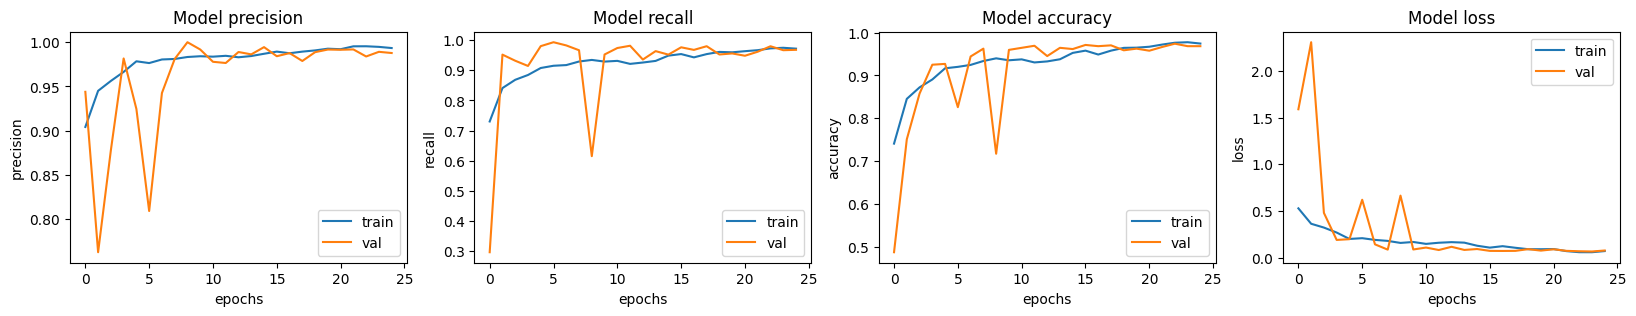

In [ ]:
# Visualize training history for precision, recall, accuracy, and loss
fig, ax = plt.subplots(1, 4, figsize=(20, 3))
ax = ax.ravel()

for i, met in enumerate(['precision', 'recall', 'accuracy', 'loss']):
    ax[i].plot(history.history[met])
    ax[i].plot(history.history['val_' + met])
    ax[i].set_title('Model {}'.format(met))
    ax[i].set_xlabel('epochs')
    ax[i].set_ylabel(met)
    ax[i].legend(['train', 'val'])

In [ ]:
# Evaluate the model on the test dataset
test_list_ds = tf.data.Dataset.list_files(os.path.join(TEST_DIR, "*", "*"))
TEST_IMAGE_COUNT = tf.data.experimental.cardinality(test_list_ds).numpy()

test_ds = test_list_ds.map(process_path, num_parallel_calls=AUTOTUNE)
test_ds = test_ds.batch(BATCH_SIZE)

loss, acc, prec, rec = model.evaluate(test_ds)
print("Test accuracy:", acc)
print("Test precision:", prec)
print("Test recall:", rec)

39/39 ━━━━━━━━━━━━━━━━━━━━ 8s 183ms/step - accuracy: 0.8157 - loss: 1.1435 - precision: 0.7778 - recall: 0.9872
Test accuracy: 0.8157051205635071
Test precision: 0.7777777910232544
Test recall: 0.9871794581413269
